In [12]:
import gzip
import json

path = r"C:\Users\rekik\Downloads/Electronics_5.json.gz"

data = []
with gzip.open(path, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        # Start with a sample of 100,000 to keep it fast
        if i >= 100000: 
            break
        data.append(json.loads(line))

print(f"Successfully loaded {len(data)} rows.")

Successfully loaded 100000 rows.


In [13]:
import pandas as pd

df = pd.DataFrame(data)
df.head()

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,image
0,5.0,67,True,"09 18, 1999",AAP7PPBU72QFM,0151004714,{'Format:': ' Hardcover'},D. C. Carrad,This is the best novel I have read in 2 or 3 y...,A star is born,937612800,NaN
1,3.0,5,True,"10 23, 2013",A2E168DTVGE6SV,0151004714,{'Format:': ' Kindle Edition'},Evy,"Pages and pages of introspection, in the style...",A stream of consciousness novel,1382486400,NaN
2,5.0,4,False,"09 2, 2008",A1ER5AYS3FQ9O3,0151004714,{'Format:': ' Paperback'},Kcorn,This is the kind of novel to read when you hav...,I'm a huge fan of the author and this one did ...,1220313600,NaN
3,5.0,13,False,"09 4, 2000",A1T17LMQABMBN5,0151004714,{'Format:': ' Hardcover'},Caf Girl Writes,What gorgeous language! What an incredible wri...,The most beautiful book I have ever read!,968025600,NaN
4,3.0,8,True,"02 4, 2000",A3QHJ0FXK33OBE,0151004714,{'Format:': ' Hardcover'},W. Shane Schmidt,I was taken in by reviews that compared this b...,A dissenting view--In part.,949622400,NaN


In [14]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   overall         100000 non-null  float64
 1   vote            17157 non-null   str    
 2   verified        100000 non-null  bool   
 3   reviewTime      100000 non-null  str    
 4   reviewerID      100000 non-null  str    
 5   asin            100000 non-null  str    
 6   style           61750 non-null   object 
 7   reviewerName    99984 non-null   str    
 8   reviewText      99986 non-null   str    
 9   summary         99992 non-null   str    
 10  unixReviewTime  100000 non-null  int64  
 11  image           1000 non-null    object 
dtypes: bool(1), float64(1), int64(1), object(2), str(7)
memory usage: 8.5+ MB


,overall,unixReviewTime
count,100000.000000,1.000000e+05
mean,4.370390,1.367236e+09
std,1.103365,1.236801e+08
min,1.000000,9.292320e+08
25%,4.000000,1.333411e+09
50%,5.000000,1.406419e+09
75%,5.000000,1.447027e+09
max,5.000000,1.526170e+09


In [15]:
df.isnull().sum()

overall               0
vote              82843
verified              0
reviewTime            0
reviewerID            0
asin                  0
style             38250
reviewerName         16
reviewText           14
summary               8
unixReviewTime        0
image             99000
dtype: int64

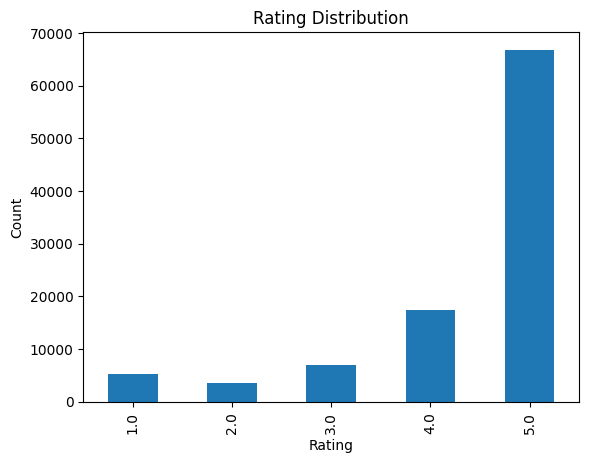

In [18]:
import matplotlib.pyplot as plt

df['overall'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

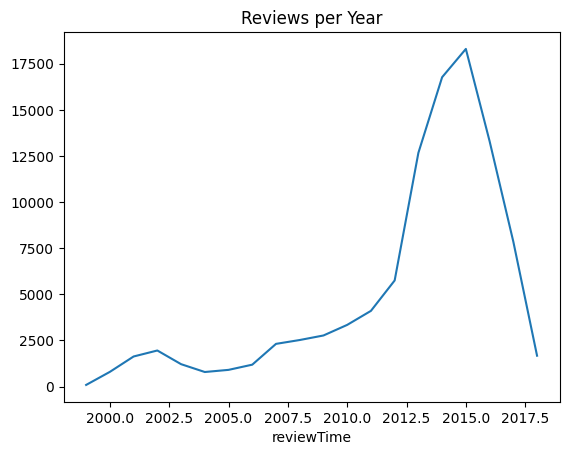

In [19]:
df['reviewTime'] = pd.to_datetime(df['reviewTime'], errors='coerce')

df['reviewTime'].dt.year.value_counts().sort_index().plot()
plt.title("Reviews per Year")
plt.show()